# J01 — Phase solide et relations masse–volume

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 1 : relations masse–volume, granulométrie, loi de Stokes, triangle textural*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les données sont dans le dossier `data/`. Exécutez la cellule suivante pour importer les bibliothèques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from scipy.special import erf

rho_w = 1.0   # masse volumique de l'eau, g/cm³

## Exercice 1 — Relations masse–volume  *(≈ 15 min)*

Le fichier `data/J01_echantillons.csv` contient 12 échantillons prélevés au cylindre ($V_t = 100$ cm³) dans deux
parcelles (`temoin` et `trafiquee`), à six profondeurs (tranches de 10 cm). Pour chacun : masse humide $M_t$,
masse sèche $M_s$ (105 °C, 24 h), masse volumique des solides $\rho_s$.

1. Calculer $\rho_b$, $w$, $\theta$, $n$, $e$, $S$ et $\theta_a$ pour chaque échantillon. Rappels :
   $\rho_b = M_s/V_t$, $w = M_w/M_s$, $\theta = w\,\rho_b/\rho_w$, $n = 1-\rho_b/\rho_s$, $e = n/(1-n)$, $S = \theta/n$, $\theta_a = n-\theta$.
2. Comparer les deux parcelles (moyennes par parcelle, graphique de $\rho_b$ et $\theta_a$ en fonction de la profondeur).
   La parcelle trafiquée est-elle compactée ? Quels échantillons ont $\theta_a < 0{,}10$ ?
3. Calculer le stock d'eau (mm) du profil 0–60 cm de chaque parcelle, chaque échantillon représentant une tranche de 10 cm.

**Lecture des données**

In [2]:
df = pd.read_csv("data/J01_echantillons.csv")
print(df)

       id   parcelle profondeur_cm  V_t_cm3  M_t_g  M_s_g  rho_s_gcm3  \
0   TEM-1     temoin          0-10    100.0  150.6  129.6        2.60   
1   TEM-2     temoin         10-20    100.0  161.2  134.1        2.60   
2   TEM-3     temoin         20-30    100.0  169.2  140.1        2.65   
3   TEM-4     temoin         30-40    100.0  166.3  136.1        2.65   
4   TEM-5     temoin         40-50    100.0  177.8  143.7        2.65   
5   TEM-6     temoin         50-60    100.0  180.6  146.7        2.65   
6   TRA-1  trafiquee          0-10    100.0  177.7  150.8        2.60   
7   TRA-2  trafiquee         10-20    100.0  188.4  162.5        2.60   
8   TRA-3  trafiquee         20-30    100.0  186.9  157.7        2.65   
9   TRA-4  trafiquee         30-40    100.0  193.9  164.7        2.65   
10  TRA-5  trafiquee         40-50    100.0  197.4  162.8        2.65   
11  TRA-6  trafiquee         50-60    100.0  196.1  167.8        2.65   

    sable_pct  argile_pct  limon_pct  
0        40

**1. Relations masse–volume**

In [3]:
# masse d'eau = masse humide - masse sèche
df["M_w"] = df["M_t_g"] - df["M_s_g"]

# masse volumique apparente (g/cm³) et teneur en eau massique (-)
df["rho_b"] = df["M_s_g"] / df["V_t_cm3"]
df["w"] = df["M_w"] / df["M_s_g"]

# teneur en eau volumique, porosité, indice des vides, saturation, porosité d'aération
df["theta"] = df["w"] * df["rho_b"] / rho_w
df["n"] = 1 - df["rho_b"] / df["rho_s_gcm3"]
df["e"] = df["n"] / (1 - df["n"])
df["S"] = df["theta"] / df["n"]
df["theta_a"] = df["n"] - df["theta"]

colonnes = ["id", "parcelle", "profondeur_cm", "rho_b", "w", "theta", "n", "e", "S", "theta_a"]
print(df[colonnes].round(3))

       id   parcelle profondeur_cm  rho_b      w  theta      n      e      S  \
0   TEM-1     temoin          0-10  1.296  0.162  0.210  0.502  1.006  0.419   
1   TEM-2     temoin         10-20  1.341  0.202  0.271  0.484  0.939  0.560   
2   TEM-3     temoin         20-30  1.401  0.208  0.291  0.471  0.892  0.617   
3   TEM-4     temoin         30-40  1.361  0.222  0.302  0.486  0.947  0.621   
4   TEM-5     temoin         40-50  1.437  0.237  0.341  0.458  0.844  0.745   
5   TEM-6     temoin         50-60  1.467  0.231  0.339  0.446  0.806  0.759   
6   TRA-1  trafiquee          0-10  1.508  0.178  0.269  0.420  0.724  0.640   
7   TRA-2  trafiquee         10-20  1.625  0.159  0.259  0.375  0.600  0.691   
8   TRA-3  trafiquee         20-30  1.577  0.185  0.292  0.405  0.680  0.721   
9   TRA-4  trafiquee         30-40  1.647  0.177  0.292  0.378  0.609  0.771   
10  TRA-5  trafiquee         40-50  1.628  0.213  0.346  0.386  0.628  0.897   
11  TRA-6  trafiquee         50-60  1.67

**2. Comparaison des deux parcelles**

           rho_b      n  theta  theta_a
parcelle                               
temoin     1.384  0.475  0.292    0.182
trafiquee  1.610  0.388  0.290    0.098


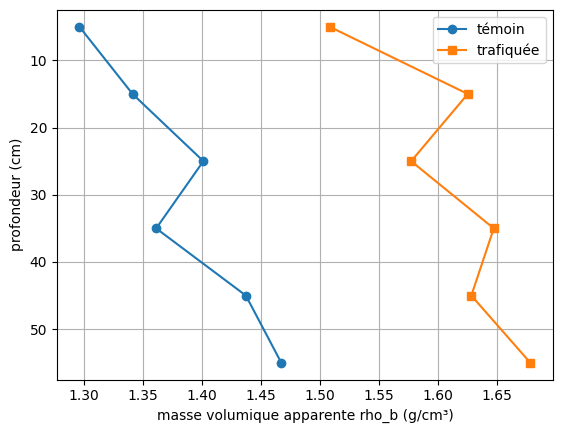

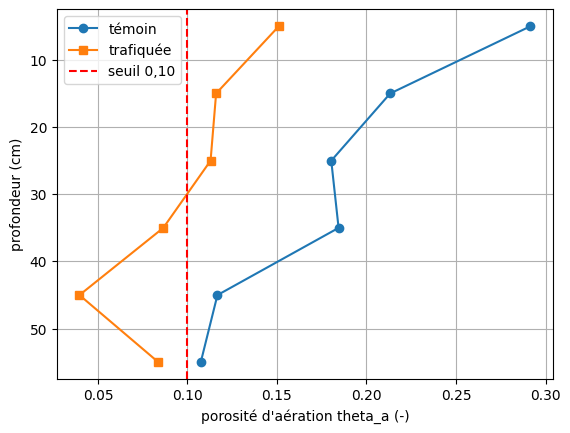

Échantillons avec theta_a < 0,10 : ['TRA-4', 'TRA-5', 'TRA-6']


In [4]:
# moyennes par parcelle
moyennes = df.groupby("parcelle")[["rho_b", "n", "theta", "theta_a"]].mean()
print(moyennes.round(3))

# profondeur du milieu de chaque tranche (cm) pour le graphique
df["z_cm"] = [5, 15, 25, 35, 45, 55, 5, 15, 25, 35, 45, 55]
temoin = df[df["parcelle"] == "temoin"]
trafiquee = df[df["parcelle"] == "trafiquee"]

plt.figure()
plt.plot(temoin["rho_b"], temoin["z_cm"], "o-", label="témoin")
plt.plot(trafiquee["rho_b"], trafiquee["z_cm"], "s-", label="trafiquée")
plt.gca().invert_yaxis()
plt.xlabel("masse volumique apparente rho_b (g/cm³)")
plt.ylabel("profondeur (cm)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(temoin["theta_a"], temoin["z_cm"], "o-", label="témoin")
plt.plot(trafiquee["theta_a"], trafiquee["z_cm"], "s-", label="trafiquée")
plt.axvline(0.10, color="red", linestyle="--", label="seuil 0,10")
plt.gca().invert_yaxis()
plt.xlabel("porosité d'aération theta_a (-)")
plt.ylabel("profondeur (cm)")
plt.legend()
plt.grid(True)
plt.show()

# échantillons mal aérés
mal_aeres = df[df["theta_a"] < 0.10]
print("Échantillons avec theta_a < 0,10 :", list(mal_aeres["id"]))

**3. Stock d'eau du profil 0–60 cm**

In [5]:
# chaque échantillon représente une tranche de 100 mm : stock = somme de theta * 100 mm
stock_temoin = temoin["theta"].sum() * 100
stock_trafiquee = trafiquee["theta"].sum() * 100
print("Stock d'eau 0-60 cm, témoin    :", round(stock_temoin, 1), "mm")
print("Stock d'eau 0-60 cm, trafiquée :", round(stock_trafiquee, 1), "mm")

Stock d'eau 0-60 cm, témoin    : 175.4 mm
Stock d'eau 0-60 cm, trafiquée : 174.1 mm


**Commentaire (instructeur).** La parcelle trafiquée a une $\rho_b$ supérieure d'environ 0,2 g/cm³ et une porosité inférieure de ~0,08 ; à teneur en eau
comparable, sa porosité d'aération tombe sous le seuil de 0,10 pour plusieurs échantillons : c'est le diagnostic classique de la compaction.
Le stock d'eau est exprimé en mm pour être comparé directement aux pluies et à l'ET (voir Jour 8).

## Exercice 2 — Courbes granulométriques  *(≈ 15 min)*

`data/J01_granulometrie.csv` donne le pourcentage passant (masse cumulée) en fonction du diamètre pour trois sols A, B, C.

1. Tracer les trois courbes cumulées (axe des diamètres en échelle logarithmique).
2. Calculer, par **interpolation linéaire en $\log d$**, les diamètres $D_{10}$, $D_{30}$, $D_{50}$, $D_{60}$ de chaque sol,
   puis $C_u = D_{60}/D_{10}$ et $C_c = D_{30}^2/(D_{10} D_{60})$.
3. Calculer les fractions argile/limon/sable selon l'USDA (2 µm, 50 µm) et selon ISO (2 µm, 63 µm).
4. Ajuster une loi log-normale $F(d) = \tfrac12[1+\mathrm{erf}((\ln d - \ln d_g)/(\sqrt2 \ln\sigma_g))]$ sur le sol A
   (`curve_fit`) et superposer la courbe ajustée.

**Lecture des données**

In [6]:
g = pd.read_csv("data/J01_granulometrie.csv")
d = g["d_mm"].to_numpy()          # diamètres (mm)
pA = g["sol_A_pct"].to_numpy()    # % passant du sol A
pB = g["sol_B_pct"].to_numpy()
pC = g["sol_C_pct"].to_numpy()
print(g)

     d_mm  sol_A_pct  sol_B_pct  sol_C_pct
0   0.001          8          1       22.0
1   0.002         18          3       38.0
2   0.005         30          4       52.0
3   0.010         38          5       62.0
4   0.020         46          6       72.0
5   0.050         62          9       88.0
6   0.063         66         12       91.0
7   0.100         75         20       95.0
8   0.250         88         60       98.0
9   0.500         96         90       99.5
10  1.000         99         98      100.0
11  2.000        100        100      100.0


**1. Courbes granulométriques**

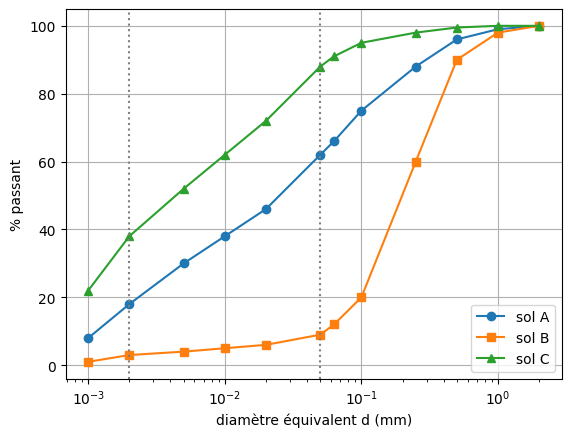

In [7]:
plt.figure()
plt.semilogx(d, pA, "o-", label="sol A")
plt.semilogx(d, pB, "s-", label="sol B")
plt.semilogx(d, pC, "^-", label="sol C")
plt.axvline(0.002, color="gray", linestyle=":")    # limite argile / limon (2 µm)
plt.axvline(0.05, color="gray", linestyle=":")     # limite limon / sable USDA (50 µm)
plt.xlabel("diamètre équivalent d (mm)")
plt.ylabel("% passant")
plt.legend()
plt.grid(True)
plt.show()

**2. Diamètres caractéristiques, Cu et Cc**

In [8]:
# diamètre tel que x % de la masse est plus fine : interpolation linéaire de log10(d) en fonction de p
def D_x(d, p, x):
    log_d = np.interp(x, p, np.log10(d))
    return 10 ** log_d

for nom, p in [("A", pA), ("B", pB), ("C", pC)]:
    D10 = D_x(d, p, 10)
    D30 = D_x(d, p, 30)
    D50 = D_x(d, p, 50)
    D60 = D_x(d, p, 60)
    Cu = D60 / D10
    Cc = D30**2 / (D10 * D60)
    print(f"sol {nom} : D10 = {D10:.4f} mm, D50 = {D50:.3f} mm, D60 = {D60:.3f} mm, Cu = {Cu:.1f}, Cc = {Cc:.2f}")

sol A : D10 = 0.0011 mm, D50 = 0.025 mm, D60 = 0.045 mm, Cu = 38.8, Cc = 0.49
sol B : D10 = 0.0540 mm, D50 = 0.199 mm, D60 = 0.250 mm, Cu = 4.6, Cc = 1.17
sol C : D10 = 0.0010 mm, D50 = 0.004 mm, D60 = 0.009 mm, Cu = 8.7, Cc = 0.23


**3. Fractions texturales USDA et ISO**

In [9]:
log_d = np.log10(d)
fractions = []
for nom, p in [("A", pA), ("B", pB), ("C", pC)]:
    # % passant à 2 µm, 50 µm et 63 µm (interpolation en log d)
    p_2um = np.interp(np.log10(0.002), log_d, p)
    p_50um = np.interp(np.log10(0.050), log_d, p)
    p_63um = np.interp(np.log10(0.063), log_d, p)
    argile = p_2um
    limon_usda = p_50um - p_2um
    sable_usda = 100 - p_50um
    limon_iso = p_63um - p_2um
    sable_iso = 100 - p_63um
    fractions.append([nom, argile, limon_usda, sable_usda, limon_iso, sable_iso])

frac = pd.DataFrame(fractions, columns=["sol", "argile", "limon_USDA", "sable_USDA", "limon_ISO", "sable_ISO"])
print(frac.round(1))

  sol  argile  limon_USDA  sable_USDA  limon_ISO  sable_ISO
0   A    18.0        44.0        38.0       48.0       34.0
1   B     3.0         6.0        91.0        9.0       88.0
2   C    38.0        50.0        12.0       53.0        9.0


**4. Loi log-normale ajustée sur le sol A**

dg = 20.9 µm, sigma_g = 9.79


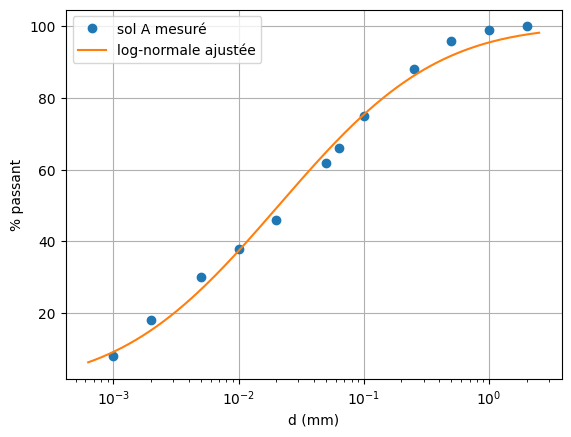

RMSE de l'ajustement : 2.67 %


In [10]:
# % passant d'une distribution log-normale de diamètre médian dg et d'écart-type géométrique sg
def F_lognormale(d, dg, sg):
    return 50 * (1 + erf((np.log(d) - np.log(dg)) / (np.sqrt(2) * np.log(sg))))

popt, pcov = curve_fit(F_lognormale, d, pA, p0=[0.02, 5])
dg = popt[0]
sg = popt[1]
print(f"dg = {dg * 1000:.1f} µm, sigma_g = {sg:.2f}")

dd = np.logspace(-3.2, 0.4, 200)
plt.figure()
plt.semilogx(d, pA, "o", label="sol A mesuré")
plt.semilogx(dd, F_lognormale(dd, dg, sg), "-", label="log-normale ajustée")
plt.xlabel("d (mm)")
plt.ylabel("% passant")
plt.legend()
plt.grid(True)
plt.show()

erreur = F_lognormale(d, dg, sg) - pA
rmse = np.sqrt(np.mean(erreur**2))
print(f"RMSE de l'ajustement : {rmse:.2f} %")

**Commentaire (instructeur).** Le sol B (sable) est uniforme ($C_u \approx 2$–3), le sol A est bien gradué. Passer de la limite USDA (50 µm) à la limite ISO (63 µm)
déplace quelques pour cent du sable vers le limon : la classe texturale peut changer, d'où l'importance de préciser le système.
L'ajustement log-normal est raisonnable pour A mais une distribution bimodale ferait mieux pour un sol à deux populations de grains.

## Exercice 3 — Loi de Stokes et sédimentation  *(≈ 10 min)*

1. Calculer la viscosité de l'eau (Pa·s) par interpolation dans la table : 5 °C : 1,519 ; 10 °C : 1,307 ; 15 °C : 1,139 ;
   20 °C : 1,002 ; 25 °C : 0,890 ; 30 °C : 0,798 (mPa·s).
2. Écrire `stokes(d, T)` qui retourne la vitesse de chute (m/s) d'une particule de diamètre $d$ (m) à la température $T$,
   avec $\rho_s = 2650$ et $\rho_w = 998$ kg/m³ : $v = g(\rho_s-\rho_w)d^2/(18\mu)$.
3. Produire la table des temps (minutes) nécessaires pour qu'une particule de 50, 20, 5 et 2 µm parcoure 10 cm, à 15, 20 et 25 °C.
4. Déterminer le diamètre pour lequel $Re = \rho_w v d/\mu = 1$ à 20 °C (limite de validité) avec `brentq`.

**1. Viscosité de l'eau**

In [11]:
T_table = np.array([5, 10, 15, 20, 25, 30])                               # °C
mu_table = np.array([1.519, 1.307, 1.139, 1.002, 0.890, 0.798]) * 1e-3    # Pa s

# viscosité dynamique (Pa s) par interpolation linéaire dans la table
def viscosite(T):
    return np.interp(T, T_table, mu_table)

print("mu(20 °C) =", viscosite(20), "Pa s")

mu(20 °C) = 0.001002 Pa s


**2. Vitesse de chute de Stokes**

In [12]:
rho_s = 2650.0    # kg/m³
rho_eau = 998.0   # kg/m³
g_pes = 9.81      # m/s²

# vitesse de chute (m/s) d'une sphère de diamètre d (m) à la température T (°C)
def stokes(d, T):
    mu = viscosite(T)
    v = g_pes * (rho_s - rho_eau) * d**2 / (18 * mu)
    return v

print("v(20 µm, 20 °C) =", stokes(20e-6, 20), "m/s")

v(20 µm, 20 °C) = 0.00035941716566866277 m/s


**3. Temps de prélèvement à 10 cm**

In [13]:
z = 0.10   # profondeur de prélèvement (m)
print("d (µm)   15 °C    20 °C    25 °C   (temps en minutes pour parcourir 10 cm)")
for d_um in [50, 20, 5, 2]:
    d_m = d_um * 1e-6
    t15 = z / stokes(d_m, 15) / 60
    t20 = z / stokes(d_m, 20) / 60
    t25 = z / stokes(d_m, 25) / 60
    print(f"{d_um:5d}   {t15:7.1f}  {t20:7.1f}  {t25:7.1f}")

d (µm)   15 °C    20 °C    25 °C   (temps en minutes pour parcourir 10 cm)
   50       0.8      0.7      0.7
   20       5.3      4.6      4.1
    5      84.3     74.2     65.9
    2     527.1    463.7    411.9


**4. Limite de validité : Re = 1**

In [14]:
# nombre de Reynolds de la particule à 20 °C, moins 1 : la racine donne le diamètre limite
def reynolds_moins_1(d):
    v = stokes(d, 20)
    Re = rho_eau * v * d / viscosite(20)
    return Re - 1

d_lim = brentq(reynolds_moins_1, 1e-6, 1e-3)
print(f"Re = 1 pour d = {d_lim * 1e6:.0f} µm : au-delà, la loi de Stokes surestime la vitesse (tamisage nécessaire).")

Re = 1 pour d = 104 µm : au-delà, la loi de Stokes surestime la vitesse (tamisage nécessaire).


**Commentaire (instructeur).** La viscosité varie de ~2,5 %/°C : une erreur de 5 °C sur la température change les temps de prélèvement de ~13 %.
Le diamètre limite (~100 µm) justifie de tamiser les sables et de ne sédimenter que les limons et argiles.

## Exercice 4 — Triangle textural  *(≈ 15 min)*

1. Programmer `classe_usda(sable, argile)` qui retourne la classe texturale USDA (12 classes) à partir des règles du triangle
   (le limon vaut $100 - $ sable $-$ argile). Rappels des règles principales : argile ≥ 40 → *argile* (sable ≤ 45, limon < 40),
   *argile limoneuse* (limon ≥ 40) ou *argile sableuse* (argile ≥ 35, sable > 45) ; 27 ≤ argile < 40 → *loam argileux*
   (20 < sable ≤ 45) ou *loam limono-argileux* (sable ≤ 20) ; 20 ≤ argile < 35, sable > 45, limon < 28 → *loam sablo-argileux* ;
   7 ≤ argile < 27, 28 ≤ limon < 50, sable ≤ 52 → *loam* ; limon ≥ 50 → *loam limoneux* (12 ≤ argile < 27, ou argile < 12 et limon < 80)
   ou *limon* (limon ≥ 80, argile < 12) ; sinon : *sable* si limon + 1,5 argile < 15, *sable loameux* si limon + 2 argile < 30,
   *loam sableux* autrement.
2. Convertir une composition en coordonnées cartésiennes du triangle ($x = 100 - $ sable $-$ argile$/2$, $y = $ argile $\cdot\sqrt3/2$)
   et tracer le contour du triangle.
3. Placer les sols A, B, C (exercice 2, fractions USDA) et les 12 échantillons de l'exercice 1 ; afficher leur classe.

**1. Classe texturale USDA**

In [15]:
def classe_usda(sable, argile):
    limon = 100 - sable - argile
    if argile >= 40 and sable <= 45 and limon < 40:
        return "argile"
    elif argile >= 40 and limon >= 40:
        return "argile limoneuse"
    elif argile >= 35 and sable > 45:
        return "argile sableuse"
    elif 27 <= argile < 40 and 20 < sable <= 45:
        return "loam argileux"
    elif 27 <= argile < 40 and sable <= 20:
        return "loam limono-argileux"
    elif 20 <= argile < 35 and sable > 45 and limon < 28:
        return "loam sablo-argileux"
    elif 7 <= argile < 27 and 28 <= limon < 50 and sable <= 52:
        return "loam"
    elif limon >= 50 and 12 <= argile < 27:
        return "loam limoneux"
    elif 50 <= limon < 80 and argile < 12:
        return "loam limoneux"
    elif limon >= 80 and argile < 12:
        return "limon"
    elif limon + 1.5 * argile < 15:
        return "sable"
    elif limon + 2 * argile < 30:
        return "sable loameux"
    else:
        return "loam sableux"

print(classe_usda(40, 20))   # attendu : loam
print(classe_usda(90, 3))    # attendu : sable

loam
sable


**2. Coordonnées et contour du triangle**

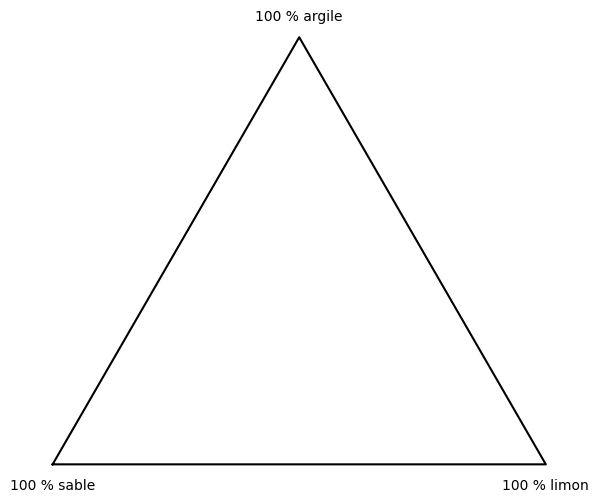

In [16]:
# coordonnées cartésiennes d'un point du triangle (sable en bas, argile en haut)
def x_tri(sable, argile):
    return 100 - sable - argile / 2

def y_tri(sable, argile):
    return argile * np.sqrt(3) / 2

# les trois sommets : 100 % sable, 100 % limon, 100 % argile
x_contour = []
y_contour = []
for s, a in [(100, 0), (0, 0), (0, 100), (100, 0)]:
    x_contour.append(x_tri(s, a))
    y_contour.append(y_tri(s, a))

plt.figure(figsize=(7, 6))
plt.plot(x_contour, y_contour, "k-")
plt.text(0, -5, "100 % sable", ha="center")
plt.text(100, -5, "100 % limon", ha="center")
plt.text(50, 90, "100 % argile", ha="center")
plt.axis("equal")
plt.axis("off")
plt.show()

**3. Placer les sols et les échantillons**

sol A : loam
sol B : sable
sol C : loam limono-argileux


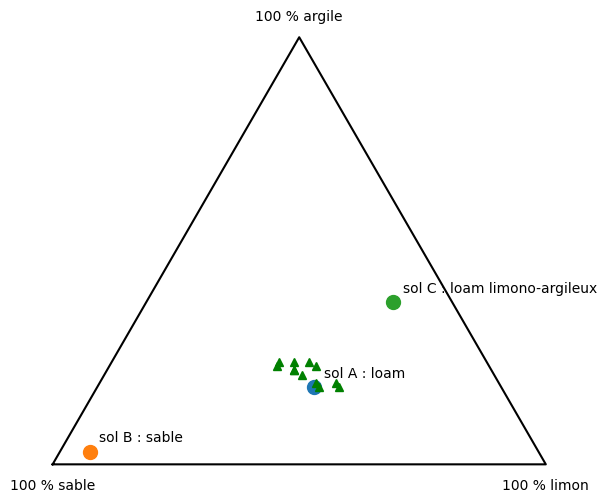

classe_USDA
loam    12
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(7, 6))
plt.plot(x_contour, y_contour, "k-")

# sols A, B, C de l'exercice 2 (fractions USDA)
for i in range(len(frac)):
    nom = frac.loc[i, "sol"]
    s = frac.loc[i, "sable_USDA"]
    a = frac.loc[i, "argile"]
    classe = classe_usda(s, a)
    plt.plot(x_tri(s, a), y_tri(s, a), "o", markersize=10)
    plt.text(x_tri(s, a) + 2, y_tri(s, a) + 2, "sol " + nom + " : " + classe)
    print("sol", nom, ":", classe)

# les 12 échantillons de l'exercice 1
for i in range(len(df)):
    s = df.loc[i, "sable_pct"]
    a = df.loc[i, "argile_pct"]
    plt.plot(x_tri(s, a), y_tri(s, a), "g^")

plt.text(0, -5, "100 % sable", ha="center")
plt.text(100, -5, "100 % limon", ha="center")
plt.text(50, 90, "100 % argile", ha="center")
plt.axis("equal")
plt.axis("off")
plt.show()

# classe de chaque échantillon
classes = []
for i in range(len(df)):
    classes.append(classe_usda(df.loc[i, "sable_pct"], df.loc[i, "argile_pct"]))
df["classe_USDA"] = classes
print(df["classe_USDA"].value_counts())

**Commentaire (instructeur).** Les 12 échantillons (38 % sable, 21 % argile) sont tous des loams ; le sol C (argile ~38 %) est un loam limono-argileux et le sol B un sable.

## Exercice 5 — Bonus — vérification numérique de l'analyse dimensionnelle  *(≈ facultatif)*

Le théorème de Buckingham appliqué à la chute d'une particule donne deux nombres sans dimension,
$\Pi_1 = v\,d\,\Delta\rho/\mu$ et $\Pi_2 = g\,d^3\,\Delta\rho^2/\mu^2$. Vérifier numériquement, pour $d$ de 1 à 60 µm,
que $\Pi_1/\Pi_2 = 1/18$ dans le régime de Stokes (à 20 °C).

**Rapport Π1/Π2**

In [18]:
mu = viscosite(20)
delta_rho = rho_s - rho_eau
for d_um in [1, 10, 20, 40, 60]:
    d_m = d_um * 1e-6
    v = stokes(d_m, 20)
    Pi1 = v * d_m * delta_rho / mu
    Pi2 = g_pes * d_m**3 * delta_rho**2 / mu**2
    print(f"d = {d_um:2d} µm : Pi1/Pi2 = {Pi1 / Pi2:.5f}")
print("1/18 =", round(1 / 18, 5))

d =  1 µm : Pi1/Pi2 = 0.05556
d = 10 µm : Pi1/Pi2 = 0.05556
d = 20 µm : Pi1/Pi2 = 0.05556
d = 40 µm : Pi1/Pi2 = 0.05556
d = 60 µm : Pi1/Pi2 = 0.05556
1/18 = 0.05556


**Commentaire (instructeur).** Le rapport Π₁/Π₂ = 1/18 est exact par construction de la loi de Stokes : les deux nombres sans dimension ne sont pas indépendants dans ce régime.

## Pour aller plus loin

* Refaire l'exercice 2 avec une distribution bimodale (somme de deux log-normales) pour le sol C.
* Estimer la surface spécifique des trois sols à partir de leur courbe granulométrique ($S_s = \sum_i f_i\, 6/(\rho_s d_i)$).